Written by Mary Letey, March 2026 with help from GPT

**NOTE!** This copy generalizes the data-generation process beyond the exponential kernel. Sampling now uses a factor of a user-supplied positive-semidefinite kernel matrix `K` on the `l + 1` context/query positions, so kernels such as squared-exponential, Matern, power-law, or a custom callable can be used without rewriting the simulation logic. The original `run.ipynb` is unchanged.

For large `n`, `d`, or `l`, tune `sample_batch_size` in the sweep functions to trade memory for runtime.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import random, lax
from jax.scipy.sparse.linalg import cg
from functools import partial
import numpy as np
import matplotlib.pyplot as plt

## **Data simulations**

In [2]:
# -----------------------
# Kernel construction + stats
# -----------------------
def _pairwise_lags(l, dtype=jnp.float64):
    idx = jnp.arange(l + 1, dtype=dtype)
    return jnp.abs(idx[:, None] - idx[None, :])


def _safe_positive_param(param, dtype):
    param = jnp.asarray(param, dtype=dtype)
    tiny = jnp.asarray(jnp.finfo(dtype).tiny, dtype=dtype)
    return jnp.maximum(param, tiny)


def kernel_exp(l, corr_len, dtype=jnp.float64):
    dist = _pairwise_lags(l, dtype)
    corr_len = jnp.asarray(corr_len, dtype=dtype)
    safe_corr_len = _safe_positive_param(corr_len, dtype)
    K = jnp.exp(-dist / safe_corr_len)
    return jnp.where(corr_len <= 0.0, jnp.eye(l + 1, dtype=dtype), K)


def kernel_squared_exp(l, corr_len, dtype=jnp.float64):
    dist = _pairwise_lags(l, dtype)
    corr_len = jnp.asarray(corr_len, dtype=dtype)
    safe_corr_len = _safe_positive_param(corr_len, dtype)
    K = jnp.exp(-0.5 * (dist / safe_corr_len) ** 2)
    return jnp.where(corr_len <= 0.0, jnp.eye(l + 1, dtype=dtype), K)


def kernel_matern32(l, corr_len, dtype=jnp.float64):
    dist = _pairwise_lags(l, dtype)
    corr_len = jnp.asarray(corr_len, dtype=dtype)
    safe_corr_len = _safe_positive_param(corr_len, dtype)
    scaled = jnp.sqrt(jnp.asarray(3.0, dtype=dtype)) * dist / safe_corr_len
    K = (1.0 + scaled) * jnp.exp(-scaled)
    return jnp.where(corr_len <= 0.0, jnp.eye(l + 1, dtype=dtype), K)


def POWER_LAW_KERNEL(l, exponent=1.0, dtype=jnp.float64):
    dist = _pairwise_lags(l, dtype)
    exponent = jnp.asarray(exponent, dtype=dtype)
    return (1.0 + dist) ** (-exponent)


def kernel_from_lag_function(l, lag_fn, dtype=jnp.float64):
    dist = _pairwise_lags(l, dtype)
    K = jnp.asarray(lag_fn(dist), dtype=dtype)
    return 0.5 * (K + K.T)


def icl_kernel_stats(K):
    k = K[:-1, -1]            # (l,)
    Ksub = K[:-1, :-1]        # (l,l)
    k0 = k @ k
    k1 = k @ (Ksub @ k)
    l_ = Ksub.shape[0]
    tk  = (1.0 / l_) * jnp.trace(Ksub)
    tk2 = (1.0 / l_) * jnp.trace(Ksub @ Ksub)
    return k0, k1, tk, tk2


def kernel_factor(K, jitter=1e-10):
    K = jnp.asarray(K)
    dtype = K.dtype
    K = 0.5 * (K + K.T)
    eye = jnp.eye(K.shape[0], dtype=dtype)
    return jnp.linalg.cholesky(K + jnp.asarray(jitter, dtype=dtype) * eye)


def prepare_kernel(K, dtype=jnp.float64, jitter=1e-10):
    K = jnp.asarray(K, dtype=dtype)
    K = 0.5 * (K + K.T)
    K_factor = kernel_factor(K, jitter=jitter)
    kernel_stats = jnp.asarray(icl_kernel_stats(K), dtype=dtype)
    return K, K_factor, kernel_stats

# -----------------------
# Generic finite-k sampler for any PSD temporal kernel
# -----------------------
def simulate_sufficient_stats_from_kernel_factor(
    key, n, d, l, rho, C, K_factor, k_tasks,
    old_w_set=None, sample_batch_size=1024,
):
    key_wset, key_batches = random.split(key, 2)
    L = l + 1

    dtype = C.dtype
    rho = jnp.asarray(rho, dtype=dtype)
    K_factor = jnp.asarray(K_factor, dtype=dtype)
    inv_sqrt_d = jnp.asarray(1, dtype) / jnp.sqrt(jnp.asarray(d, dtype))

    sqrtC = jnp.linalg.cholesky(C + jnp.asarray(1e-12, dtype) * jnp.eye(d, dtype=dtype))
    if old_w_set is None:
        w_set = random.normal(key_wset, (k_tasks, d), dtype=dtype) @ sqrtC.T
    else:
        w_set = old_w_set

    if sample_batch_size is None:
        batch_size = int(n)
    else:
        batch_size = min(int(sample_batch_size), int(n))
    if batch_size <= 0:
        raise ValueError('sample_batch_size must be positive')

    num_batches = (int(n) + batch_size - 1) // batch_size
    n_padded = num_batches * batch_size
    batch_keys = random.split(key_batches, num_batches)

    def sample_batch(batch_key):
        key_widx, key_x, key_e = random.split(batch_key, 3)
        w_idx = random.randint(key_widx, (batch_size,), 0, k_tasks)
        w = w_set[w_idx]  # (batch_size,d)

        z = random.normal(key_x, (batch_size, L, d), dtype=dtype)
        x_all = jnp.einsum('ts,bsd->btd', K_factor, z) * inv_sqrt_d
        e_all = random.normal(key_e, (batch_size, L), dtype=dtype) * jnp.sqrt(rho)
        y_all = jnp.einsum('btd,bd->bt', x_all, w) + e_all

        if l == 0:
            y_sum_x = jnp.zeros((batch_size, d), dtype=dtype)
            y_sum_y = jnp.zeros((batch_size,), dtype=dtype)
        else:
            x_context = x_all[:, :l, :]
            y_context = y_all[:, :l]
            y_sum_x = jnp.einsum('bt,btd->bd', y_context, x_context)
            y_sum_y = jnp.sum(y_context * y_context, axis=1)

        x_last = x_all[:, l, :]
        y_last = y_all[:, l]
        return x_last, y_sum_x, y_sum_y, y_last

    x_last_b, y_sum_x_b, y_sum_y_b, y_last_b = lax.map(sample_batch, batch_keys)

    x_last = x_last_b.reshape(n_padded, d)[:n]
    y_sum_x = y_sum_x_b.reshape(n_padded, d)[:n]
    y_sum_y = y_sum_y_b.reshape(n_padded)[:n]
    y_last = y_last_b.reshape(n_padded)[:n]

    return x_last, y_sum_x, y_sum_y, y_last, w_set


def simulate_sufficient_stats_finite_k(
    key, n, d, l, rho, C, K, k_tasks,
    old_w_set=None, sample_batch_size=1024, kernel_jitter=1e-10,
):
    _, K_factor, _ = prepare_kernel(K, dtype=C.dtype, jitter=kernel_jitter)
    return simulate_sufficient_stats_from_kernel_factor(
        key, n, d, l, rho, C, K_factor, k_tasks,
        old_w_set=old_w_set, sample_batch_size=sample_batch_size,
    )


def simulate_sufficient_stats_INDEPENDENT_QUERY(
    key, n, d, l, rho, C, K, k_tasks,
    old_w_set=None, sample_batch_size=1024, kernel_jitter=1e-10,
):
    K = jnp.asarray(K, dtype=C.dtype)
    K_ind = K.at[:l, -1].set(0.0).at[-1, :l].set(0.0)
    _, K_factor, _ = prepare_kernel(K_ind, dtype=C.dtype, jitter=kernel_jitter)
    return simulate_sufficient_stats_from_kernel_factor(
        key, n, d, l, rho, C, K_factor, k_tasks,
        old_w_set=old_w_set, sample_batch_size=sample_batch_size,
    )

# -----------------------
# Matrix-free H and H^T operators
# -----------------------
def Hv(v_mat, x_l, y_sum_x, y_sum_y, d, l):
    vA = v_mat[:, :d]     # (d,d)
    v_last = v_mat[:, d]  # (d,)

    tmp = y_sum_x @ vA.T
    term1 = (d / l) * jnp.sum(x_l * tmp, axis=1)
    term2 = (1.0 / l) * y_sum_y * (x_l @ v_last)
    return term1 + term2

def HTu(u, x_l, y_sum_x, y_sum_y, d, l):
    Xu = x_l * u[:, None]
    A = (d / l) * (Xu.T @ y_sum_x)
    b = (1.0 / l) * (x_l.T @ (u * y_sum_y))
    return jnp.concatenate([A, b[:, None]], axis=1)

# -----------------------
# ICL trace formula
# -----------------------
# THIS IS ONE OF THE TRACE FORMULAS, WHICH ASSUMES THAT
# k0, k1, k2 are all O(1) wrt ell. 
# THIS IS THE FORMULA GIVEN BY LEMMA 1 IN APPENDIX C OF THE TEXT.
def ICL_trace_from_Gamma(Gamma, d, l, rho, C_test, k0, k1, tk, tk2, alpha):
    tc = (1.0 / d) * jnp.trace(C_test)
    rho1 = rho + tk * tc
    rho2 = tk * rho + tk2 * tc

    A_left = tk * C_test + (d / l) * k0 * tc * jnp.eye(d, dtype=C_test.dtype)
    B_tl   = (tk * tk) * C_test + rho2 * (d / l) * jnp.eye(d, dtype=C_test.dtype)
    B_br   = rho1 * rho1

    Gamma_sq = Gamma[:, :d]
    tr_gamma_sigma = (1.0 / d) * jnp.trace(Gamma_sq)
    tr_gamma_sigmaCsigma = (1.0 / d) * jnp.trace(Gamma_sq @ C_test)

    tensor_term = (
        (1.0 / (alpha * alpha)) * (k1 * tc + k0 * rho) * (tr_gamma_sigma ** 2)
        + (2.0 / alpha) * k0 * tk * tr_gamma_sigma * tr_gamma_sigmaCsigma
    )

    tr_GA = jnp.trace(Gamma_sq @ A_left.T)

    last_col = Gamma[:, d]
    tr_GBG = jnp.trace(Gamma_sq @ B_tl @ Gamma_sq.T) + B_br * (last_col @ last_col)

    return rho + tc - (2.0 / d) * tr_GA + (1.0 / d) * tr_GBG + tensor_term

# -----------------------
# ICL trace formula
# -----------------------
# THIS IS THE OTHER TRACE FORMULA, WHICH ASSUMES THAT
# k0, k1, k2 are all O(ell) wrt ell. 
# THIS IS THE FORMULA GIVEN BY LEMMA 2 IN APPENDIX C OF THE TEXT.
def ICL_trace_from_Gamma_PROPORTIONAL(Gamma, d, l, rho, k0, k1, tk, tk2, alpha):
    k0_tilde = k0/l
    k1_tilde = k1/(l**2)
    k2_tilde = tk2/l
    
    Gamma_sq = Gamma[:, :d]

    return 1 + rho - 2*k0_tilde*jnp.trace(Gamma_sq) + k2_tilde*jnp.trace(Gamma_sq @ Gamma_sq.T) + k1_tilde*jnp.trace(Gamma_sq @ Gamma_sq) + k1_tilde*(jnp.trace(Gamma_sq)**2)

# -----------------------
# Per-sample predictor from Gamma
# -----------------------
# This computes the predictor
# yhat = <Gamma, H> 
# given some matrix Gamma and the x,y data need to compute H.
def predict_from_Gamma(Gamma, x_l, y_sum_x, y_sum_y, d, l):
    Gamma_A = Gamma[:, :d]   # (d,d)
    Gamma_b = Gamma[:, d]    # (d,)

    # First block contribution:
    term1 = (d / l) * jnp.sum((x_l @ Gamma_A) * y_sum_x, axis=1)
    # Last column contribution:
    term2 = (1.0 / l) * y_sum_y * (x_l @ Gamma_b)

    return term1 + term2

# -----------------------
# Direct Monte Carlo MSE from fresh sampled data
# -----------------------
# This function simulates the test population averaging of the MSE loss
# E_test [ (y - yhat)^2 ] using n_eval samples
def mse_from_data(key, Gamma, n_eval, d, l, rho, C, K_factor, sample_batch_size=1024):
    x_l, y_sum_x, y_sum_y, y_last, _ = simulate_sufficient_stats_from_kernel_factor(
        key, n_eval, d, l, rho, C, K_factor, 2*n_eval,
        sample_batch_size=sample_batch_size,
    )
    y_hat = predict_from_Gamma(Gamma, x_l, y_sum_x, y_sum_y, d, l)
    mse = jnp.mean((y_hat - y_last) ** 2)
    return mse, y_hat, y_last

# -----------------------
# Conjugate gradient solution for Gamma
# -----------------------
def gamma_cg_operator(x_l, y_sum_x, y_sum_y, y_last, n, d, l, lambdareg, cg_tol=1e-10, cg_maxiter=5000):

    p = d * (d + 1)
    reg = (n / d) * lambdareg

    def matvec(v_flat):
        v_mat = v_flat.reshape(d, d + 1)
        hv = Hv(v_mat, x_l, y_sum_x, y_sum_y, d, l)
        ht_h_v = HTu(hv, x_l, y_sum_x, y_sum_y, d, l)
        return (reg * v_mat + ht_h_v).reshape(p)

    b_mat = HTu(y_last, x_l, y_sum_x, y_sum_y, d, l)
    b = b_mat.reshape(p)

    gamma, _ = cg(matvec, b, tol=cg_tol, maxiter=cg_maxiter)

    # report residual
    r = b - matvec(gamma)
    rel_res = jnp.linalg.norm(r) / (jnp.linalg.norm(b) + 1e-30)

    return gamma.reshape(d, d + 1), rel_res
    
# -----------------------
# One pass over Gamma error
# -----------------------
def one_replicate(
    key, n, d, l, rho, C, C_test, K_factor, kernel_stats,
    lambdareg, alpha, k_tasks, cg_tol, cg_maxiter, sample_batch_size,
):
    k0, k1, tk, tk2 = kernel_stats

    x_l, y_sum_x, y_sum_y, y_last, _ = simulate_sufficient_stats_from_kernel_factor(
        key, n, d, l, rho, C, K_factor, k_tasks,
        sample_batch_size=sample_batch_size,
    )

    Gamma, _ = gamma_cg_operator(x_l, y_sum_x, y_sum_y, y_last, n, d, l, lambdareg, cg_tol, cg_maxiter)

    error_data, _, _ = mse_from_data(
        5*key, Gamma, n_eval=2*n, d=d, l=l, rho=rho, C=C_test,
        K_factor=K_factor, sample_batch_size=sample_batch_size,
    )
    error_trace_const = ICL_trace_from_Gamma(
        Gamma, d, l, jnp.asarray(rho, C.dtype), C_test,
        k0, k1, tk, tk2, jnp.asarray(alpha, C.dtype),
    )
    error_trace_prop = ICL_trace_from_Gamma_PROPORTIONAL(
        Gamma, d, l, jnp.asarray(rho, C.dtype),
        k0, k1, tk, tk2, jnp.asarray(alpha, C.dtype),
    )
    
    return error_data, error_trace_const, error_trace_prop
# -----------------------
# Multiple passes to average over Gamma error
# -----------------------
@partial(jax.jit, static_argnames=("numavg", "n", "d", "l", "k_tasks", "cg_maxiter", "sample_batch_size"))
def avg_over_replicates(
    base_key, numavg, n, d, l, rho, C, C_test, K_factor, kernel_stats,
    lambdareg, alpha, k_tasks, cg_tol=1e-4, cg_maxiter=200, sample_batch_size=1024,
):
    keys = random.split(base_key, numavg)

    dtype = C.dtype
    init = (
        jnp.asarray(0, dtype=jnp.int32),         # count
        jnp.zeros((3,), dtype=dtype),            # mean
        jnp.zeros((3,), dtype=dtype),            # M2
    )

    def body(state, k):
        count, mean, M2 = state

        x, y, z = one_replicate(
            k, n, d, l, rho, C, C_test, K_factor, kernel_stats,
            lambdareg, alpha, k_tasks, cg_tol, cg_maxiter, sample_batch_size)

        vals = jnp.stack([x, y, z])  

        count_new = count + 1
        delta = vals - mean
        mean_new = mean + delta / count_new
        delta2 = vals - mean_new
        M2_new = M2 + delta * delta2

        return (count_new, mean_new, M2_new), vals

    (count, mean, M2), errs = lax.scan(body, init, keys)

    var = jnp.where(
        count > 1,
        M2 / (count - 1),
        jnp.zeros((3,), dtype=dtype)
    )
    std = jnp.sqrt(var)

    return mean, std, errs


def run_sweep_over_corr_lens_POWERLAW(
    gammas, seed=0, d=32, tau=0.5, alpha=1.0, kappa=1.0,
    rho=0.01, numavg=20, lambdareg=1e-6,
    cg_tol=1e-4, cg_maxiter=200,
    kernel_jitter=1e-10, sample_batch_size=1024,
):
    l = int(alpha * d)
    n = int(tau * d * d)
    k_tasks = int(kappa * d)

    C = jnp.eye(d, dtype=jnp.float64)
    C_test = C
    key = random.PRNGKey(seed)
    samples = []
    stds = []

    for gamma in list(gammas):
        key, subkey = random.split(key)
        K = POWER_LAW_KERNEL(l, exponent=gamma, dtype=C.dtype)
        _, K_factor, kernel_stats = prepare_kernel(K, dtype=C.dtype, jitter=kernel_jitter)
        val_mean, val_std, _ = avg_over_replicates(
            subkey, numavg, n, d, l, rho, C, C_test, K_factor, kernel_stats,
            lambdareg, alpha, k_tasks, cg_tol, cg_maxiter, sample_batch_size,
        )
        samples.append(val_mean)
        stds.append(val_std)

    return jnp.stack(samples), jnp.stack(stds)


## **Transition between Constant and Proportional**

In [3]:
tau = 4.0
alpha = 1.0
kappa = 0.5
rho = 0.01
numavg = 20
lambdareg = 1e-8

deez = [16, 32]

means = {}
sts = {}
lens = {}

for d in deez:
    l = int(alpha*d)
    lens[d] = np.logspace(np.log10(0.01), np.log10(50*l), 20) 
    means[d], sts[d] = run_sweep_over_corr_lens_POWERLAW(lens[d], seed=0, d=d, tau=tau, alpha=alpha, kappa=kappa,
                rho=rho, numavg=numavg, lambdareg=lambdareg,
                cg_tol=1e-8, cg_maxiter=2000) 
    print(f"{d} is done")

16 is done
32 is done


In [4]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",

    "axes.unicode_minus": False,
    "axes.formatter.use_mathtext": True,

    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

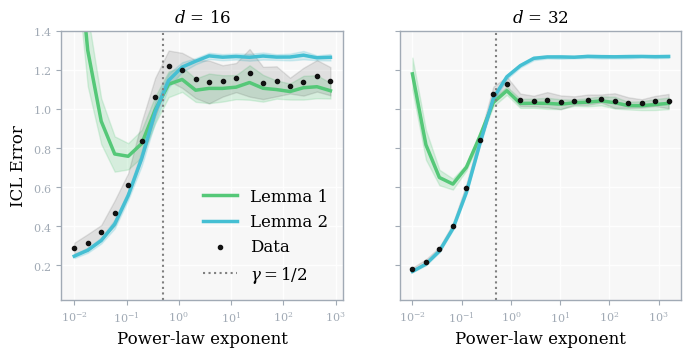

In [10]:
length=4*len(deez)
fig, axes = plt.subplots(1, len(deez), figsize=(length, 3.5), sharey=True)

SPINE_COLOR = "#A1AAB5"
colors = [
    "#111111",
    "#55C878",
    "#45BFD3",
]

for i, d in enumerate(deez):
    axes[i].plot(lens[d], means[d][:,1], label='Lemma 1', color=colors[1], lw=2.5)#, ms=5) 
    axes[i].fill_between(lens[d], np.array(means[d][:,1])-np.array(sts[d][:,1]), np.array(means[d][:,1])+np.array(sts[d][:,1]), alpha=0.2, color=colors[1]) 
    axes[i].plot(lens[d], means[d][:,2], label='Lemma 2', color=colors[2], lw=2.5)#, ms=5) 
    axes[i].fill_between(lens[d], np.array(means[d][:,2])-np.array(sts[d][:,2]), np.array(means[d][:,2])+np.array(sts[d][:,2]), alpha=0.2, color=colors[2]) 
    axes[i].scatter(lens[d], means[d][:,0], marker='.', label='Data', color=colors[0],zorder=5) 
    axes[i].fill_between(lens[d], np.array(means[d][:,0])-np.array(sts[d][:,0]), np.array(means[d][:,0])+np.array(sts[d][:,0]), alpha=0.1, color=colors[0])

    axes[i].set_xscale('log')
    axes[i].set_title(rf'$d$ = {d}', fontsize=12) 
    axes[i].set_xlabel(r'Power-law exponent', fontsize=12)
    
    axes[i].axvline(1/2, linestyle=':', color='gray', label=r'$\gamma = 1/2$')

    x_vals = [0.01,0.1,1,10,100,1000]
    axes[i].set_xticks(x_vals)
    axes[i].tick_params(axis="both", labelsize=8, color=SPINE_COLOR, labelcolor=SPINE_COLOR)
    axes[i].minorticks_off()
    for spine in axes[i].spines.values():
            spine.set_color(SPINE_COLOR)
            spine.set_linewidth(1.0)
    axes[i].set_ylim(0.02,1.4)
    
for ax in axes:
    ax.set_facecolor("#F7F7F7")   
    ax.grid(
        True,
        which="major",
        color="white",
        linewidth=1.0,
        alpha=0.9
    )
    ax.grid(
        True,
        which="minor",
        color="white",
        linewidth=0.5,
        alpha=0.45
    )
    ax.set_axisbelow(True)
    
axes[0].legend(fontsize=12,frameon=False)
axes[0].set_ylabel('ICL Error', fontsize=12)
fig.savefig('POWERLAW_transition.png',bbox_inches='tight')